<style>
.jp-RenderedHTMLCommon table,
.rendered_html table {
  margin-left: 0 !important;
  margin-right: auto !important;
}
.jp-RenderedHTMLCommon th,
.jp-RenderedHTMLCommon td,
.rendered_html th,
.rendered_html td {
  text-align: left !important;
}
</style>

# 05 - Data Visualization with Matplotlib and Seaborn

<div style="background:#F7FAFC; border:1px solid #D9E2EC; border-left:6px solid #2F80ED; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/goal.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Notebook Header</b><br>
<b>Day:</b> Day 1 - EDA and preprocessing foundations<br>
<b>Difficulty:</b> Beginner<br>
<b>Estimated time:</b> 75-90 minutes<br>
<b>Prerequisites:</b> Notebook 04 completed<br>
<b>Output:</b> You will create and interpret common EDA charts.<br>
<b>Next notebook:</b> Scaling, normalization, and encoding
</div>

<details>
<summary><b>Instructor talk track</b></summary>

Teach charts as answers to questions, not as decoration. For every chart, ask: What question does this chart answer? What pattern do we see? What should we check next?

</details>

## <img src="../../../assets/icons/map.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Learning Map

By the end of this notebook, you should be able to:

- Explain why visualization is useful
- Choose a chart based on a question
- Create bar charts, line charts, histograms, box plots, and scatter plots
- Use Matplotlib for chart control
- Use Seaborn for statistical charts
- Write observations from charts

## <img src="../../../assets/icons/loop.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Signature Learning Loop

```text
QUESTION -> DATA -> CODE -> EVIDENCE -> DECISION
```


## <img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Concept 1: Why Visualization Matters

<div style="background:#EAF3FF; border-left:6px solid #2F80ED; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Concept</b><br>
Visualization helps us see patterns faster than reading rows manually.
</div>

### Visualization helps answer questions like

- Which category is highest?
- How are values distributed?
- Are there unusual values?
- Do two numeric columns move together?
- Does one group spend more than another group?

<div style="background:#E9F8EF; border-left:6px solid #27AE60; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/code.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Code Lab</b><br>
Import libraries and load the cleaned customer dataset.
</div>


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

current = Path.cwd().resolve()
project_root = current

for candidate in [current, *current.parents]:
    if candidate.name == "applied_ds_ml":
        project_root = candidate
        break

data_path = project_root / "data" / "customer_activity_clean.csv"

if not data_path.exists():
    raise FileNotFoundError("Run Notebook 03 first so data/customer_activity_clean.csv is created.")

customers = pd.read_csv(data_path)
customers


,customer_id,name,city,membership,monthly_spend,visits_per_month,signup_month
0,101,Asha,Mumbai,Gold,1200.0,4.0,Jan
1,102,Ravi,Delhi,Silver,850.0,3.0,Feb
2,103,Meera,Chennai,Gold,1450.0,5.0,Feb
3,104,John,Mumbai,Bronze,700.0,2.0,Mar
4,105,Fatima,Unknown,Silver,1025.0,6.0,Apr
5,106,Chen,Chennai,Gold,1600.0,5.0,Apr
6,107,Sara,Delhi,Unknown,950.0,4.0,May
7,108,Vikram,Mumbai,Bronze,1025.0,1.0,Jun
8,109,Nina,Delhi,Silver,1100.0,4.0,Jun


## <img src="../../../assets/icons/recap.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Chart Selection Guide

<table style="margin-left:0; margin-right:auto; border-collapse:collapse; text-align:left;">
  <thead>
    <tr>
      <th style="text-align:left; padding:6px 12px;">Question</th>
      <th style="text-align:left; padding:6px 12px;">Chart type</th>
      <th style="text-align:left; padding:6px 12px;">Example</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="text-align:left; padding:6px 12px;">Compare categories</td><td style="text-align:left; padding:6px 12px;">Bar chart</td><td style="text-align:left; padding:6px 12px;">Average spend by membership</td></tr>
    <tr><td style="text-align:left; padding:6px 12px;">Show ordered trend</td><td style="text-align:left; padding:6px 12px;">Line chart</td><td style="text-align:left; padding:6px 12px;">Average spend by signup month</td></tr>
    <tr><td style="text-align:left; padding:6px 12px;">See distribution</td><td style="text-align:left; padding:6px 12px;">Histogram</td><td style="text-align:left; padding:6px 12px;">Monthly spend distribution</td></tr>
    <tr><td style="text-align:left; padding:6px 12px;">Compare spread by group</td><td style="text-align:left; padding:6px 12px;">Box plot</td><td style="text-align:left; padding:6px 12px;">Spend by membership</td></tr>
    <tr><td style="text-align:left; padding:6px 12px;">Compare two numeric columns</td><td style="text-align:left; padding:6px 12px;">Scatter plot</td><td style="text-align:left; padding:6px 12px;">Visits vs spend</td></tr>
  </tbody>
</table>


## <img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Concept 2: Bar Chart

<div style="background:#EAF3FF; border-left:6px solid #2F80ED; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Concept</b><br>
A bar chart compares values across categories.
</div>

### Question

Which membership type has the highest average monthly spend?

<div style="background:#E9F8EF; border-left:6px solid #27AE60; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/code.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Code Lab</b><br>
Create a bar chart of average monthly spend by membership.
</div>


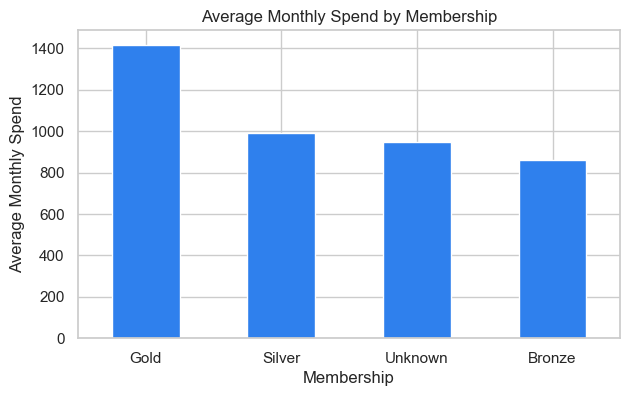

In [3]:
membership_spend = customers.groupby("membership")["monthly_spend"].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
membership_spend.plot(kind="bar", color="#2F80ED")
plt.title("Average Monthly Spend by Membership")
plt.xlabel("Membership")
plt.ylabel("Average Monthly Spend")
plt.xticks(rotation=0)
plt.show()


## <img src="../../../assets/icons/read-output.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Read the Output: Bar Chart

- Identify the tallest bar.
- That category has the highest average value.
- Compare categories using height, not color.

<div style="background:#FFF8E1; border-left:6px solid #F2C94C; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/read-output.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Observation format</b><br>
The membership type with the highest average monthly spend is ____.
</div>


## <img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Concept 3: Line Chart

<div style="background:#EAF3FF; border-left:6px solid #2F80ED; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Concept</b><br>
A line chart shows change across an ordered sequence.
</div>

### Question

How does average monthly spend change across signup months?

<div style="background:#E9F8EF; border-left:6px solid #27AE60; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/code.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Code Lab</b><br>
Create a line chart using signup month order.
</div>


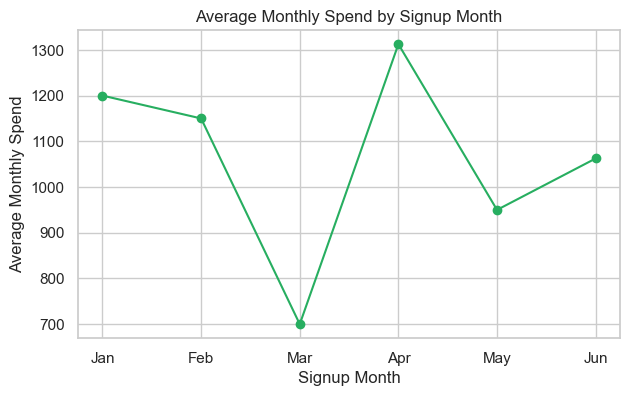

In [4]:
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
monthly_trend = customers.groupby("signup_month")["monthly_spend"].mean().reindex(month_order)

plt.figure(figsize=(7, 4))
plt.plot(monthly_trend.index, monthly_trend.values, marker="o", color="#27AE60")
plt.title("Average Monthly Spend by Signup Month")
plt.xlabel("Signup Month")
plt.ylabel("Average Monthly Spend")
plt.show()


## <img src="../../../assets/icons/read-output.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Read the Output: Line Chart

- Look at the direction of the line.
- Identify where values rise or fall.
- Do not over-explain a trend when there are only a few rows.

<div style="background:#FFECEC; border-left:6px solid #EB5757; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/caution.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Caution</b><br>
A small dataset can show a pattern, but the pattern may not be stable. Treat it as practice, not a final business conclusion.
</div>


## <img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Concept 4: Histogram

<div style="background:#EAF3FF; border-left:6px solid #2F80ED; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Concept</b><br>
A histogram shows the distribution of one numeric column.
</div>

### Question

Are monthly spend values mostly low, middle, or high?

<div style="background:#E9F8EF; border-left:6px solid #27AE60; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/code.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Code Lab</b><br>
Create a histogram of monthly spend.
</div>


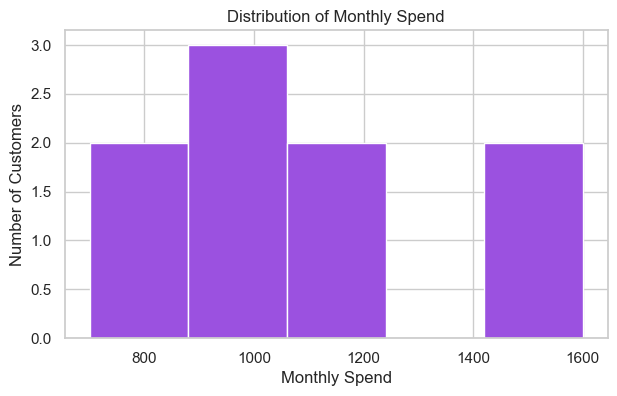

In [5]:
plt.figure(figsize=(7, 4))
plt.hist(customers["monthly_spend"], bins=5, color="#9B51E0", edgecolor="white")
plt.title("Distribution of Monthly Spend")
plt.xlabel("Monthly Spend")
plt.ylabel("Number of Customers")
plt.show()


## <img src="../../../assets/icons/read-output.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Read the Output: Histogram

- Each bar represents a value range.
- Taller bars mean more values fall in that range.
- Histograms help us understand distribution shape.

<div style="background:#FFF8E1; border-left:6px solid #F2C94C; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/read-output.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Observation format</b><br>
Most monthly spend values appear to fall between ____ and ____.
</div>


## <img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Concept 5: Box Plot

<div style="background:#EAF3FF; border-left:6px solid #2F80ED; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Concept</b><br>
A box plot summarizes spread and helps compare groups.
</div>

### Box plot is useful for

- Comparing spread across categories
- Finding middle range
- Spotting unusual values

<div style="background:#E9F8EF; border-left:6px solid #27AE60; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/code.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Code Lab</b><br>
Create a box plot of monthly spend by membership.
</div>


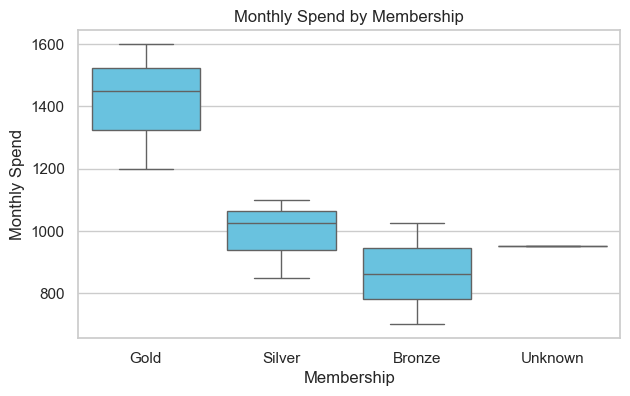

In [6]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=customers, x="membership", y="monthly_spend", color="#56CCF2")
plt.title("Monthly Spend by Membership")
plt.xlabel("Membership")
plt.ylabel("Monthly Spend")
plt.show()


## <img src="../../../assets/icons/read-output.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Read the Output: Box Plot

- Compare the middle line of each box.
- Compare the height of each box.
- A taller box means more spread in the middle values.

<div style="background:#FFF8E1; border-left:6px solid #F2C94C; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/read-output.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Observation format</b><br>
The membership type with the widest spending spread appears to be ____.
</div>


## <img src="../../../assets/icons/practice.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Checkpoint 1: Chart Choice

Choose the best chart type:

1. Compare customer count by city
2. Show monthly spend distribution
3. Compare spend spread by membership
4. Show average spend across signup months

<div style="background:#FFF8E1; border-left:6px solid #F2C94C; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/read-output.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Expected thinking</b><br>
The chart type should match the question. Do not choose charts randomly.
</div>


## <img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Concept 6: Scatter Plot

<div style="background:#EAF3FF; border-left:6px solid #2F80ED; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Concept</b><br>
A scatter plot compares two numeric columns.
</div>

### Question

Do customers with more visits also tend to spend more?

<div style="background:#E9F8EF; border-left:6px solid #27AE60; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/code.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Code Lab</b><br>
Create a scatter plot of visits per month vs monthly spend.
</div>


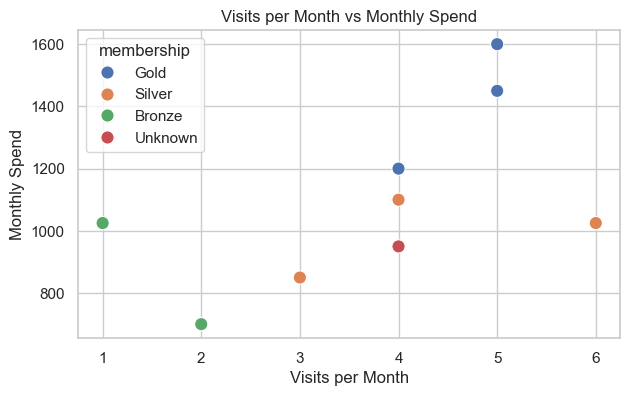

In [7]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=customers, x="visits_per_month", y="monthly_spend", hue="membership", s=90)
plt.title("Visits per Month vs Monthly Spend")
plt.xlabel("Visits per Month")
plt.ylabel("Monthly Spend")
plt.show()


## <img src="../../../assets/icons/read-output.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Read the Output: Scatter Plot

- Look for upward, downward, or no clear pattern.
- Each dot represents one customer.
- Color shows membership type.

<div style="background:#FFECEC; border-left:6px solid #EB5757; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/caution.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Caution</b><br>
A scatter plot can show association, but it does not prove cause.
</div>


## <img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Concept 7: Seaborn Count Plot

<div style="background:#EAF3FF; border-left:6px solid #2F80ED; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Concept</b><br>
A count plot shows how many rows belong to each category.
</div>

### Question

How many customers are in each city?

<div style="background:#E9F8EF; border-left:6px solid #27AE60; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/code.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Code Lab</b><br>
Create a count plot for city.
</div>


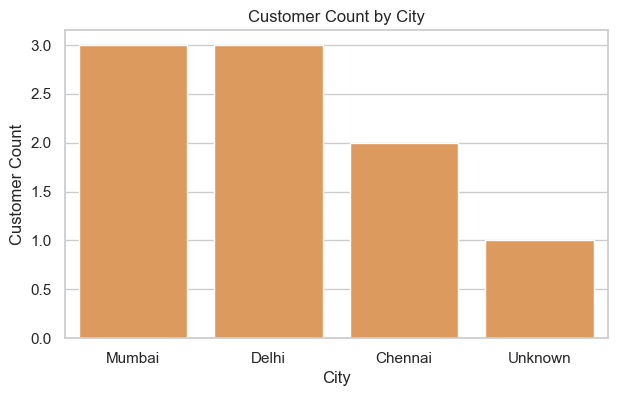

In [8]:
plt.figure(figsize=(7, 4))
sns.countplot(data=customers, x="city", order=customers["city"].value_counts().index, color="#F2994A")
plt.title("Customer Count by City")
plt.xlabel("City")
plt.ylabel("Customer Count")
plt.show()


## <img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Concept 8: Better Chart Formatting

<div style="background:#EAF3FF; border-left:6px solid #2F80ED; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/concept.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Concept</b><br>
A chart should be easy to read without extra explanation.
</div>

### Good chart habits

- Add a clear title
- Label the x-axis
- Label the y-axis
- Avoid unnecessary colors
- Keep text readable

<div style="background:#E9F8EF; border-left:6px solid #27AE60; padding:14px; border-radius:6px;">
<img src="../../../assets/icons/code.svg" width="22" style="vertical-align:middle; margin-right:6px;"><b>Code Lab</b><br>
Create a formatted horizontal bar chart for city counts.
</div>


In [ ]:
city_counts = customers["city"].value_counts().sort_values()

plt.figure(figsize=(7, 4))
plt.barh(city_counts.index, city_counts.values, color="#2D9CDB")
plt.title("Customer Count by City")
plt.xlabel("Customer Count")
plt.ylabel("City")
plt.tight_layout()
plt.show()


## <img src="../../../assets/icons/recap.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Visualization Summary Table

<table style="margin-left:0; margin-right:auto; border-collapse:collapse; text-align:left;">
  <thead>
    <tr>
      <th style="text-align:left; padding:6px 12px;">Chart</th>
      <th style="text-align:left; padding:6px 12px;">Best for</th>
      <th style="text-align:left; padding:6px 12px;">Main question</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="text-align:left; padding:6px 12px;">Bar chart</td><td style="text-align:left; padding:6px 12px;">Category comparison</td><td style="text-align:left; padding:6px 12px;">Which category is higher?</td></tr>
    <tr><td style="text-align:left; padding:6px 12px;">Line chart</td><td style="text-align:left; padding:6px 12px;">Ordered trend</td><td style="text-align:left; padding:6px 12px;">How does it change?</td></tr>
    <tr><td style="text-align:left; padding:6px 12px;">Histogram</td><td style="text-align:left; padding:6px 12px;">Distribution</td><td style="text-align:left; padding:6px 12px;">Where do values concentrate?</td></tr>
    <tr><td style="text-align:left; padding:6px 12px;">Box plot</td><td style="text-align:left; padding:6px 12px;">Spread by group</td><td style="text-align:left; padding:6px 12px;">Which group varies more?</td></tr>
    <tr><td style="text-align:left; padding:6px 12px;">Scatter plot</td><td style="text-align:left; padding:6px 12px;">Two numeric columns</td><td style="text-align:left; padding:6px 12px;">Do they move together?</td></tr>
    <tr><td style="text-align:left; padding:6px 12px;">Count plot</td><td style="text-align:left; padding:6px 12px;">Category counts</td><td style="text-align:left; padding:6px 12px;">How many rows per category?</td></tr>
  </tbody>
</table>


## <img src="../../../assets/icons/caution.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Common Mistakes to Avoid

<div style="background:#FFECEC; border-left:6px solid #EB5757; padding:14px; border-radius:6px;">
<b>Read this before practice.</b>
</div>

- Choosing a chart before deciding the question.
- Using a line chart for categories with no natural order.
- Forgetting chart titles and axis labels.
- Using too many colors without meaning.
- Treating a small practice dataset as a final business conclusion.
- Saying a scatter plot proves cause.


## <img src="../../../assets/icons/practice.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Practice Task

Complete these tasks:

1. Create a bar chart showing average `visits_per_month` by `membership`.
2. Create a histogram for `visits_per_month`.
3. Create a box plot of `monthly_spend` by `city`.
4. Create a scatter plot of `visits_per_month` and `monthly_spend` without color.
5. Write one observation for each chart.

## <img src="../../../assets/icons/practice.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Exit Ticket

Answer these before closing the notebook:

1. Which chart compares categories?
2. Which chart shows distribution?
3. Which chart compares two numeric columns?
4. Why do titles and axis labels matter?
5. Why should every chart start from a question?

## <img src="../../../assets/icons/recap.svg" width="22" style="vertical-align:middle; margin-right:6px;"> Ready for the Next Notebook

You are ready for the next notebook if you can:

- Choose a chart based on a question.
- Create bar, line, histogram, box, and scatter plots.
- Add chart titles and axis labels.
- Read the main pattern from a chart.
- Write chart observations in plain English.
